In [129]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from skimage.feature import peak_local_max
from skimage.filters import gaussian
from barnacles import *

## Load images

Images and masks are cropped to exclude the region outside of the window

In [132]:
base_path = Path().resolve()

In [136]:
img1_path = base_path / 'data/cropped_img1.png'
mask1_path = base_path / 'data//cropped_mask_1.png'

img2_path = base_path / 'data/cropped_img2.png'
mask2_path = base_path / 'data/cropped_mask_2.png'

sample1_path = base_path / 'data/img1_sample.png'
sample2_path = base_path / 'data/img2_sample.png'

Get samples of each image to use as sanity checks

In [137]:
img1_pil = Image.open(img1_path)
img2_pil = Image.open(img2_path)

w1, h1 = img1_pil.size
w2, h2 = img2_pil.size

size = 300 

left1, top1 = (w1 - size) // 2, (h1 - size) // 2
left2, top2 = (w2 - size) // 2, (h2 - size) // 2

img1_pil.crop((left1, top1, left1 + size, top1 + size)).save(sample1_path)
img2_pil.crop((left2, top2, left2 + size, top2 + size)).save(sample2_path)

In [138]:
img1_sample = load_image_bw(sample1_path)
img2_sample = load_image_bw(sample2_path, thresh=120) # tuned threshold

### Visualize Samples

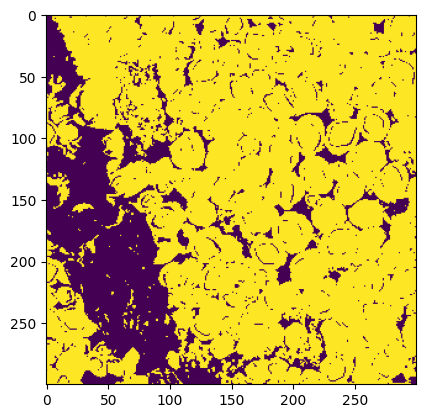

In [139]:
plt.imshow(img1_sample)

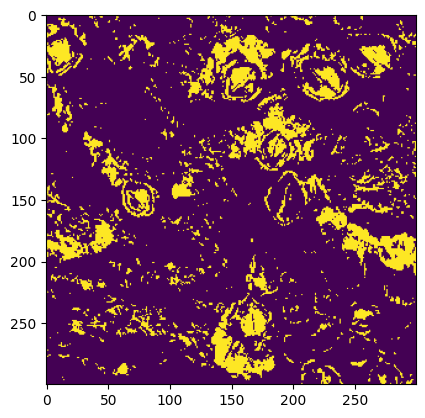

In [140]:
plt.imshow(img2_sample)

## Tune hyperparameters

The hyperparameters in the function calls below were already manually tuned; however, feel free to play around with them and see for yourself how changing them alters the region detection

Detected 130 regions


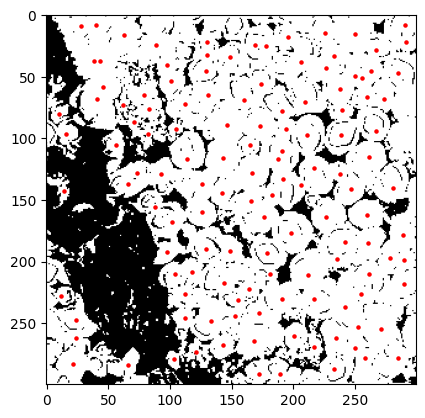

130

In [141]:
# Image 1:
find_peaks(img1_sample, sigma=3, min_dist=5)

Detected 41 regions


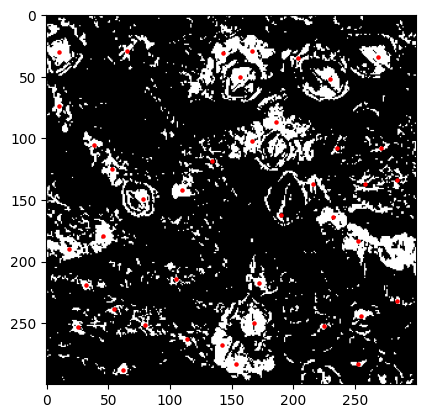

41

In [142]:
# Image 2:
find_peaks(img2_sample, sigma=5, min_dist=10)

Note that image 2 is MUCH harder, or at least for this method, since the texture of the rock background forms "local maximums" in brightness. For image types like this, find_peaks will likely overcount the number of barnacles. Therefore, it should probably be used as an upper bound on the number of barnacles.

## Inference

In [143]:
img1 = load_image_bw(img1_path)
img2 = load_image_bw(img2_path, thresh=120) # tuned threshold

Detected 1761 regions


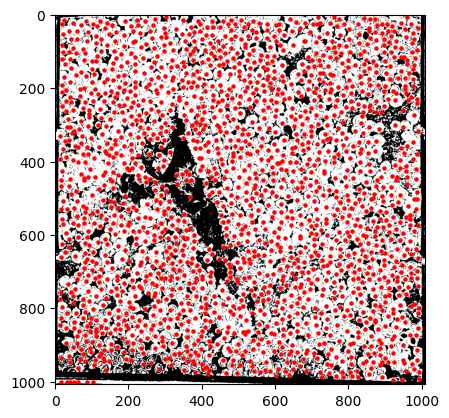

1761

In [144]:
# Image 1:
find_peaks(img1, sigma=3, min_dist=5)

Detected 647 regions


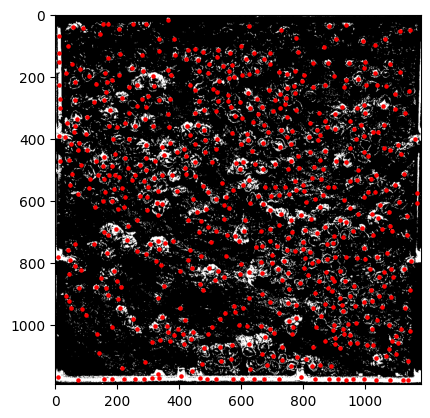

647

In [145]:
# Image 2:
find_peaks(img2, sigma=5, min_dist=10)

## Evaluate Performance

Comparing the result of find_peaks with the number of connected components in the mask (e.g., the actual number of barnacles in the image).

In [146]:
connected_components(mask1_path)

1720

In [147]:
connected_components(mask2_path)

399

find_peaks works surprisingly well on the first image! However, as predicted, it overestimates the number of barnacles in the second. Nonetheless, the scientists can play around with the hyperparameters to identify one pair that overcounts the barnacles in image 2, and another pair that undercounts, to yield a reasonable range of values.